<a href="https://colab.research.google.com/github/void-coder-x/DABA_SIG/blob/main/PS1_Network_Anomaly_MITRE_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 🔐 PS1 – Network Anomaly Detection & MITRE ATT&CK RAG Prototype

### SIG-DABA – Security Analytics Project

**Problem Statement:**
Detect anomalous network traffic logs using unsupervised clustering, and deploy a RAG assistant grounded in MITRE ATT&CK documentation to recommend threat mitigation strategies.

---

### Objective

The objective of this problem statement is to develop an initial end-to-end cybersecurity prototype that:

- Processes network traffic logs.
- Detects unusual network traffic using unsupervised clustering.
- Calculates anomaly scores for network flows.
- Retrieves relevant MITRE ATT&CK information.
- Demonstrates a basic RAG workflow for threat analysis and mitigation guidance.

---

### Overall Workflow

Network Traffic
      ↓
Data Preprocessing
      ↓
Feature Scaling
      ↓
Unsupervised Clustering
      ↓
Anomaly Detection
      ↓
Suspicious Network Flow
      ↓
Behavior Description
      ↓
MITRE ATT&CK Retrieval
      ↓
Candidate Techniques
      ↓
Mitigation Information

In [ ]:

---

# CELL 2 — Markdown
### Project Architecture

```markdown
## 🧠 PS1 System Architecture

```text
┌──────────────────────────────┐
│     CICIDS2017 Dataset       │
└──────────────┬───────────────┘
               ↓
┌──────────────────────────────┐
│     Data Preprocessing       │
└──────────────┬───────────────┘
               ↓
┌──────────────────────────────┐
│      Feature Scaling         │
└──────────────┬───────────────┘
               ↓
┌──────────────────────────────┐
│      K-Means Clustering      │
└──────────────┬───────────────┘
               ↓
┌──────────────────────────────┐
│      Anomaly Detection       │
└──────────────┬───────────────┘
               ↓
       Suspicious Flow
               ↓
┌──────────────────────────────┐
│    Behavior Description      │
└──────────────┬───────────────┘
               ↓
┌──────────────────────────────┐
│     MITRE ATT&CK Retrieval   │
└──────────────┬───────────────┘
               ↓
┌──────────────────────────────┐
│ Candidate Techniques &       │
│ Mitigation Information       │
└──────────────────────────────┘

In [ ]:
# CELL 3 — Markdown
### Technologies

```markdown
## 🛠️ Technologies Used

| Technology | Purpose |
|---|---|
| Python | Main programming language |
| Google Colab | Development environment |
| Pandas | Data processing |
| NumPy | Numerical operations |
| Scikit-learn | Scaling and K-Means clustering |
| Matplotlib | Visualization |
| Transformers | Text embeddings |
| FAISS | Similarity search |
| MITRE ATT&CK | Cybersecurity knowledge source |

In [1]:
# ============================================
# PS1 - Environment Setup
# ============================================

!pip -q install pandas numpy scikit-learn matplotlib seaborn requests faiss-cpu transformers

import os
import json
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import faiss
import torch

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings("ignore")

print("Environment ready")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 87.5 MB/s eta 0:00:00
Environment ready
PyTorch version: 2.11.0+cpu
CUDA available: False


In [ ]:
## 📊 Dataset

This project uses the CICIDS2017 network traffic dataset.

The dataset contains network-flow features representing different types of network activity.

For this prototype:

- Network features are used for unsupervised clustering.
- The `Label` column is retained for evaluation only.
- Attack labels are not supplied to K-Means during training.

In [2]:
# ============================================
# Upload CICIDS2017 Dataset
# ============================================

from google.colab import files

uploaded = files.upload()

csv_files = [name for name in uploaded.keys() if name.lower().endswith(".csv")]

if not csv_files:
    raise FileNotFoundError("Please upload a CSV network traffic dataset.")

DATASET_PATH = csv_files[0]

print("Dataset selected:", DATASET_PATH)

Saving Friday-WorkingHours-Morning.pcap_ISCX.csv to Friday-WorkingHours-Morning.pcap_ISCX.csv
Dataset selected: Friday-WorkingHours-Morning.pcap_ISCX.csv


In [3]:
# ============================================
# Load Dataset
# ============================================

df = pd.read_csv(DATASET_PATH)

print("Original dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn count:", len(df.columns))

Original dataset shape: (191033, 79)

First 5 rows:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3268,112740690,32,16,6448,1152,403,0,201.5,204.724205,...,32,3.594286e+02,1.199802e+01,380,343,16100000.0,4.988048e+05,16400000,15400000,BENIGN
1,389,112740560,32,16,6448,5056,403,0,201.5,204.724205,...,32,3.202857e+02,1.574499e+01,330,285,16100000.0,4.987937e+05,16400000,15400000,BENIGN
2,0,113757377,545,0,0,0,0,0,0.0,0.000000,...,0,9.361829e+06,7.324646e+06,18900000,19,12200000.0,6.935824e+06,20800000,5504997,BENIGN
3,5355,100126,22,0,616,0,28,28,28.0,0.000000,...,32,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
4,0,54760,4,0,0,0,0,0,0.0,0.000000,...,0,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN



Column count: 79


In [4]:
# ============================================
# Clean Column Names
# ============================================

df.columns = df.columns.str.strip()

print("Label column exists:", "Label" in df.columns)

print("\nFirst 15 columns:")
print(df.columns[:15].tolist())

Label column exists: True

First 15 columns:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s']


In [5]:
# ============================================
# Inspect Dataset Labels
# ============================================

if "Label" not in df.columns:
    raise ValueError("The dataset must contain a 'Label' column.")

print("Label distribution:")
display(df["Label"].value_counts())

Label distribution:


,count
Label,
BENIGN,189067
Bot,1966


In [ ]:
## 🧹 Data Preprocessing

The following preprocessing steps are performed:

1. Remove leading/trailing spaces from column names.
2. Convert infinite values into missing values.
3. Remove rows containing invalid values.
4. Separate the `Label` column from the feature matrix.
5. Remove duplicate feature columns.
6. Remove constant features.
7. Convert remaining features to numeric values.
8. Standardize the feature matrix.

The label is not used as an input to the unsupervised clustering algorithm.

In [6]:
# ============================================
# Check Missing and Infinite Values
# ============================================

numeric_before = df.drop(columns=["Label"]).apply(
    pd.to_numeric, errors="coerce"
)

missing_before = numeric_before.isna().sum().sum()
infinite_before = np.isinf(numeric_before.to_numpy()).sum()

print("Missing values:", missing_before)
print("Infinite values:", infinite_before)

Missing values: 28
Infinite values: 216


In [7]:
# ============================================
# Convert Features to Numeric
# ============================================

labels = df["Label"].astype(str).str.strip()

X_raw = df.drop(columns=["Label"]).copy()

# Convert every feature to numeric
X_raw = X_raw.apply(pd.to_numeric, errors="coerce")

# Replace infinity with NaN
X_raw = X_raw.replace([np.inf, -np.inf], np.nan)

# Remove rows containing NaN
valid_rows = ~X_raw.isna().any(axis=1)

X_clean = X_raw.loc[valid_rows].reset_index(drop=True)
y_clean = labels.loc[valid_rows].reset_index(drop=True)

print("Rows after invalid-value removal:", len(X_clean))
print("Features before duplicate removal:", X_clean.shape[1])

Rows after invalid-value removal: 190911
Features before duplicate removal: 78


In [8]:
# ============================================
# Remove Duplicate Feature Columns
# ============================================

duplicate_columns = X_clean.T.duplicated()

duplicate_names = X_clean.columns[duplicate_columns].tolist()

X_clean = X_clean.loc[:, ~duplicate_columns]

print("Duplicate columns removed:", len(duplicate_names))
print("Remaining features:", X_clean.shape[1])

if duplicate_names:
    print("\nRemoved duplicate columns:")
    print(duplicate_names)

Duplicate columns removed: 16
Remaining features: 62

Removed duplicate columns:
['Fwd URG Flags', 'Bwd URG Flags', 'SYN Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Avg Fwd Segment Size', 'Fwd Header Length.1', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets']


In [9]:
# ============================================
# Remove Constant Features
# ============================================

constant_columns = [
    col for col in X_clean.columns
    if X_clean[col].nunique() <= 1
]

X_clean = X_clean.drop(columns=constant_columns)

print("Constant columns removed:", len(constant_columns))

if constant_columns:
    print("Removed:", constant_columns)

print("Final feature count:", X_clean.shape[1])

Constant columns removed: 1
Removed: ['Bwd PSH Flags']
Final feature count: 61


In [10]:
# ============================================
# Preprocessing Summary
# ============================================

print("========== PREPROCESSING SUMMARY ==========")
print("Original rows:", len(df))
print("Rows after cleaning:", len(X_clean))
print("Original features:", len(df.columns) - 1)
print("Final features:", X_clean.shape[1])
print("Labels available:", y_clean.nunique())
print("\nLabel distribution after cleaning:")
display(y_clean.value_counts())

========== PREPROCESSING SUMMARY ==========
Original rows: 191033
Rows after cleaning: 190911
Original features: 78
Final features: 61
Labels available: 2

Label distribution after cleaning:


,count
Label,
BENIGN,188955
Bot,1956


In [ ]:
## 📏 Feature Scaling

K-Means uses distances to determine cluster membership.

Therefore, the numerical network features are standardized so that features with large numerical ranges do not dominate the clustering process.

In [11]:
# ============================================
# Feature Scaling
# ============================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_clean)

print("Scaled feature matrix shape:", X_scaled.shape)
print("Mean of first feature:", X_scaled[:, 0].mean())
print("Std of first feature:", X_scaled[:, 0].std())

Scaled feature matrix shape: (190911, 61)
Mean of first feature: 7.696792628774073e-17
Std of first feature: 1.0000000000000002


In [ ]:
## 🤖 Unsupervised Clustering

K-Means clustering is used to group network flows based on similarity.

The clustering algorithm does not use the `Label` column.

For this initial PS1 prototype, four clusters are used.

The selected value is an experimental prototype setting. Detailed clustering analysis and workflow refinement belong to PS2.

In [12]:
# ============================================
# K-Means Clustering
# ============================================

N_CLUSTERS = 4

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

print("K-Means completed.")
print("Number of clusters:", N_CLUSTERS)

K-Means completed.
Number of clusters: 4


Cluster distribution:


,Number of Flows
0,33923
1,152619
2,6
3,4363


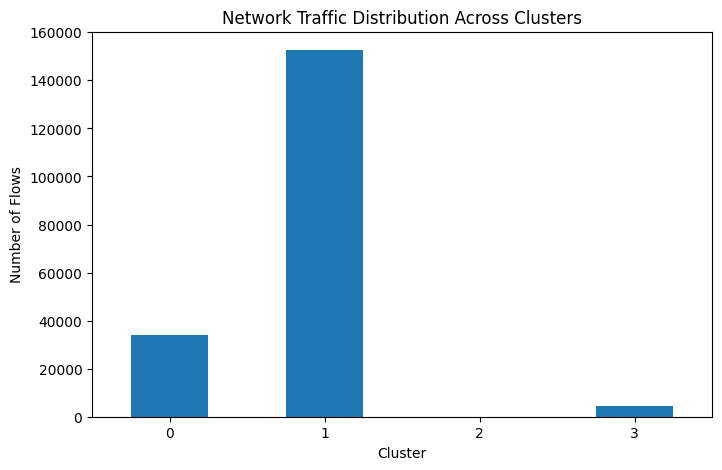

In [13]:
# ============================================
# Cluster Distribution
# ============================================

cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()

print("Cluster distribution:")
display(cluster_counts.to_frame("Number of Flows"))

plt.figure(figsize=(8, 5))
cluster_counts.plot(kind="bar")
plt.title("Network Traffic Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Flows")
plt.xticks(rotation=0)
plt.show()

In [ ]:
## 🚨 Anomaly Detection

After clustering, the distance between each network flow and its assigned cluster centroid is calculated.

A larger distance means that the flow is less similar to the center of its assigned cluster.

This distance is used as the prototype's anomaly score.

In [14]:
# ============================================
# Calculate Anomaly Score
# ============================================

cluster_centers = kmeans.cluster_centers_

anomaly_scores = np.linalg.norm(
    X_scaled - cluster_centers[cluster_labels],
    axis=1
)

results = X_clean.copy()

results["Label"] = y_clean
results["Cluster"] = cluster_labels
results["Anomaly_Score"] = anomaly_scores

print("Anomaly scores calculated.")

display(
    results[
        ["Label", "Cluster", "Anomaly_Score"]
    ].head()
)

Anomaly scores calculated.


,Label,Cluster,Anomaly_Score
0,BENIGN,0,8.922197
1,BENIGN,0,9.269225
2,BENIGN,0,24.127621
3,BENIGN,1,2.300282
4,BENIGN,1,4.763205


In [ ]:
## 🎯 Anomaly Threshold

An initial **95th percentile** threshold is used for the prototype.

This means that flows with anomaly scores above the 95th percentile are flagged as suspicious.

> This is an experimental threshold for PS1 and should not be interpreted as a universal cybersecurity threshold.

In [15]:
# ============================================
# Detect Anomalies
# ============================================

ANOMALY_PERCENTILE = 95

threshold = np.percentile(
    results["Anomaly_Score"],
    ANOMALY_PERCENTILE
)

results["Predicted_Anomaly"] = (
    results["Anomaly_Score"] > threshold
).astype(int)

print("Anomaly threshold:", threshold)
print(
    "Detected anomalies:",
    results["Predicted_Anomaly"].sum()
)
print(
    "Total flows:",
    len(results)
)

Anomaly threshold: 10.894147262766612
Detected anomalies: 9546
Total flows: 190911


In [16]:
# ============================================
# Top Anomalous Network Flows
# ============================================

top_anomalies = results.sort_values(
    "Anomaly_Score",
    ascending=False
).head(10)

print("Top 10 anomalous network flows:")

display(
    top_anomalies[
        ["Label", "Cluster", "Anomaly_Score", "Predicted_Anomaly"]
    ]
)

Top 10 anomalous network flows:


,Label,Cluster,Anomaly_Score,Predicted_Anomaly
18338,BENIGN,0,212.200790,1
93666,BENIGN,0,200.996838,1
56587,BENIGN,0,198.767145,1
117753,BENIGN,0,163.803763,1
117780,BENIGN,0,158.146933,1
69593,BENIGN,0,152.579626,1
84744,BENIGN,0,138.276144,1
72329,BENIGN,0,137.887427,1
114693,BENIGN,0,125.936221,1
115553,BENIGN,0,125.077515,1


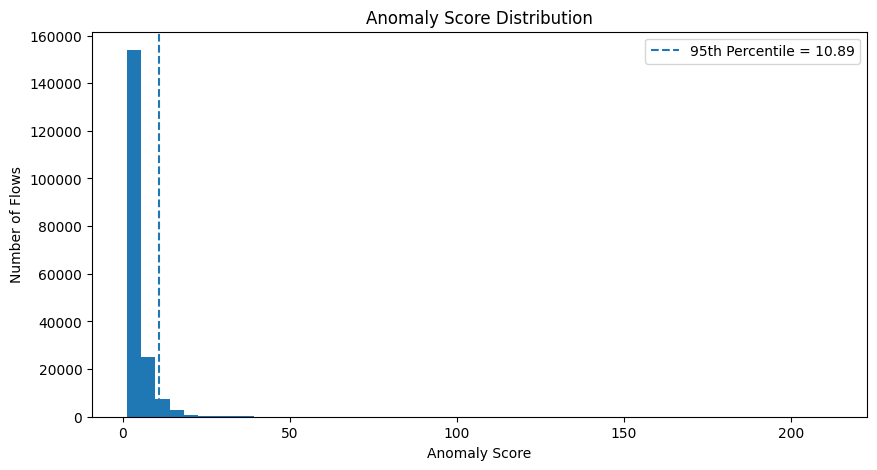

In [17]:
# ============================================
# Anomaly Score Distribution
# ============================================

plt.figure(figsize=(10, 5))

plt.hist(
    results["Anomaly_Score"],
    bins=50
)

plt.axvline(
    threshold,
    linestyle="--",
    label=f"95th Percentile = {threshold:.2f}"
)

plt.title("Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Number of Flows")
plt.legend()

plt.show()

In [ ]:
## 📊 Prototype Evaluation

The original dataset labels are used only after clustering to compare the detected anomalies with the available ground truth.

They are not used during K-Means training.

This evaluation is included only as an initial sanity check. Detailed evaluation belongs to PS8.

In [18]:
# ============================================
# Optional Ground-Truth Evaluation
# ============================================

results["Actual_Anomaly"] = (
    results["Label"].str.upper() != "BENIGN"
).astype(int)

print("Classification Report:")
print(
    classification_report(
        results["Actual_Anomaly"],
        results["Predicted_Anomaly"],
        zero_division=0
    )
)

print("\nConfusion Matrix:")

cm = confusion_matrix(
    results["Actual_Anomaly"],
    results["Predicted_Anomaly"]
)

display(
    pd.DataFrame(
        cm,
        index=["Actual Normal", "Actual Anomaly"],
        columns=["Predicted Normal", "Predicted Anomaly"]
    )
)

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97    188955
           1       0.01      0.04      0.01      1956

    accuracy                           0.94    190911
   macro avg       0.50      0.50      0.49    190911
weighted avg       0.98      0.94      0.96    190911


Confusion Matrix:


,Predicted Normal,Predicted Anomaly
Actual Normal,179491,9464
Actual Anomaly,1874,82


In [ ]:
## 🛡️ MITRE ATT&CK Knowledge Source

MITRE ATT&CK Enterprise information is used as the cybersecurity knowledge source.

For this prototype, ATT&CK techniques and mitigations are extracted from the Enterprise ATT&CK STIX dataset.

The retrieved information is used as contextual evidence for the anomaly analysis.

> PS4 will later focus specifically on building and indexing the complete MITRE ATT&CK knowledge base.

In [19]:
# ============================================
# Download MITRE ATT&CK Enterprise STIX Data
# ============================================

MITRE_URL = (
    "https://raw.githubusercontent.com/"
    "mitre-attack/attack-stix-data/master/"
    "enterprise-attack/enterprise-attack.json"
)

response = requests.get(MITRE_URL, timeout=60)
response.raise_for_status()

attack_data = response.json()

print("MITRE ATT&CK data downloaded.")
print("Total STIX objects:", len(attack_data["objects"]))

MITRE ATT&CK data downloaded.
Total STIX objects: 26086


In [20]:
# ============================================
# Extract MITRE Techniques and Mitigations
# ============================================

techniques = []
mitigations = []

for obj in attack_data["objects"]:

    if obj.get("type") not in [
        "attack-pattern",
        "course-of-action"
    ]:
        continue

    external_refs = obj.get("external_references", [])

    mitre_ref = next(
        (
            ref for ref in external_refs
            if ref.get("source_name") == "mitre-attack"
        ),
        None
    )

    if not mitre_ref:
        continue

    item = {
        "id": mitre_ref.get("external_id"),
        "name": obj.get("name", ""),
        "description": obj.get("description", ""),
        "type": obj.get("type", "")
    }

    if obj.get("type") == "attack-pattern":
        techniques.append(item)

    elif obj.get("type") == "course-of-action":
        mitigations.append(item)

print("Techniques:", len(techniques))
print("Mitigations:", len(mitigations))

Techniques: 858
Mitigations: 268


In [21]:
# ============================================
# Build MITRE Retrieval Documents
# ============================================

mitre_documents = []

for item in techniques:

    text = (
        f"MITRE ATT&CK Technique: {item['id']} - {item['name']}\n"
        f"Description: {item['description']}"
    )

    mitre_documents.append({
        "id": item["id"],
        "name": item["name"],
        "type": "technique",
        "text": text
    })


for item in mitigations:

    text = (
        f"MITRE ATT&CK Mitigation: {item['id']} - {item['name']}\n"
        f"Description: {item['description']}"
    )

    mitre_documents.append({
        "id": item["id"],
        "name": item["name"],
        "type": "mitigation",
        "text": text
    })


print("Total retrieval documents:", len(mitre_documents))

display(pd.DataFrame(mitre_documents).head())

Total retrieval documents: 1126


,id,name,type,text
0,T1055.011,Extra Window Memory Injection,technique,MITRE ATT&CK Technique: T1055.011 - Extra Wind...
1,T1053.005,Scheduled Task,technique,MITRE ATT&CK Technique: T1053.005 - Scheduled ...
2,T1205.002,Socket Filters,technique,MITRE ATT&CK Technique: T1205.002 - Socket Fil...
3,T1066,Indicator Removal from Tools,technique,MITRE ATT&CK Technique: T1066 - Indicator Remo...
4,T1560.001,Archive via Utility,technique,MITRE ATT&CK Technique: T1560.001 - Archive vi...


In [ ]:
## 🔎 Semantic Retrieval

To connect the suspicious network behavior with MITRE ATT&CK information, the textual descriptions are converted into vector embeddings.

The vectors are then indexed using FAISS.

```text
MITRE Documents
      ↓
Text Embeddings
      ↓
FAISS Vector Index
      ↓
Similarity Search

In [23]:


# CELL 34 — Code
### Load MiniLM
# ============================================
# Load Embedding Model
# ============================================

from transformers import AutoTokenizer, AutoModel

EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL)

embedding_model = AutoModel.from_pretrained(
    EMBEDDING_MODEL
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

embedding_model = embedding_model.to(device)
embedding_model.eval()

print("Embedding model loaded.")
print("Device:", device)

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding model loaded.
Device: cpu


In [24]:
# ============================================
# Mean Pooling
# ============================================

def mean_pooling(model_output, attention_mask):

    token_embeddings = model_output.last_hidden_state

    input_mask_expanded = (
        attention_mask
        .unsqueeze(-1)
        .expand(token_embeddings.size())
        .float()
    )

    return torch.sum(
        token_embeddings * input_mask_expanded,
        dim=1
    ) / torch.clamp(
        input_mask_expanded.sum(dim=1),
        min=1e-9
    )

In [25]:
# ============================================
# Generate Text Embeddings
# ============================================

def generate_embeddings(texts, batch_size=32):

    all_embeddings = []

    for start in range(0, len(texts), batch_size):

        batch = texts[start:start + batch_size]

        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=256,
            return_tensors="pt"
        )

        encoded = {
            key: value.to(device)
            for key, value in encoded.items()
        }

        with torch.no_grad():

            model_output = embedding_model(
                **encoded
            )

        embeddings = mean_pooling(
            model_output,
            encoded["attention_mask"]
        )

        embeddings = torch.nn.functional.normalize(
            embeddings,
            p=2,
            dim=1
        )

        all_embeddings.append(
            embeddings.cpu().numpy()
        )

    return np.vstack(all_embeddings)

In [26]:
# ============================================
# Generate MITRE Embeddings
# ============================================

mitre_texts = [
    doc["text"]
    for doc in mitre_documents
]

mitre_embeddings = generate_embeddings(
    mitre_texts,
    batch_size=32
)

print("Embedding matrix shape:", mitre_embeddings.shape)

Embedding matrix shape: (1126, 384)


In [27]:
# ============================================
# Build FAISS Index
# ============================================

embedding_dimension = mitre_embeddings.shape[1]

index = faiss.IndexFlatIP(
    embedding_dimension
)

index.add(
    mitre_embeddings.astype("float32")
)

print("FAISS index created.")
print("Indexed documents:", index.ntotal)

FAISS index created.
Indexed documents: 1126


In [ ]:
## 🚨 End-to-End RAG Demonstration

The most anomalous network flow is selected for the prototype demonstration.

Its network characteristics are converted into a simple behavioral description before querying the MITRE ATT&CK knowledge source.

The retrieved techniques should be treated as **candidate matches requiring further investigation**, not as proof that a specific attack technique occurred.

In [28]:
# ============================================
# Select Most Anomalous Flow
# ============================================

most_anomalous = results.sort_values(
    "Anomaly_Score",
    ascending=False
).iloc[0]

print("Most anomalous flow:")
display(
    most_anomalous[
        [
            "Label",
            "Cluster",
            "Anomaly_Score",
            "Predicted_Anomaly"
        ]
    ].to_frame()
)

Most anomalous flow:


,18338
Label,BENIGN
Cluster,0
Anomaly_Score,212.20079
Predicted_Anomaly,1


In [29]:
# ============================================
# Create Human-Readable Behavior Description
# ============================================

def create_behavior_description(row):

    return f"""
A network flow has been identified as unusually different
from the behavior represented by its assigned cluster.

Cluster: {int(row['Cluster'])}
Anomaly score: {row['Anomaly_Score']:.4f}

The flow should be investigated for potentially suspicious
network behavior. Identify relevant MITRE ATT&CK techniques
only when supported by the available behavioral evidence.
"""


behavior_description = create_behavior_description(
    most_anomalous
)

print(behavior_description)


A network flow has been identified as unusually different
from the behavior represented by its assigned cluster.

Cluster: 0
Anomaly score: 212.2008

The flow should be investigated for potentially suspicious
network behavior. Identify relevant MITRE ATT&CK techniques
only when supported by the available behavioral evidence.



In [30]:
# ============================================
# Retrieve Relevant MITRE Documents
# ============================================

query_embedding = generate_embeddings(
    [behavior_description]
)

query_embedding = query_embedding.astype("float32")

TOP_K = 5

scores, indices = index.search(
    query_embedding,
    TOP_K
)

retrieved_docs = []

for score, idx in zip(scores[0], indices[0]):

    doc = mitre_documents[idx].copy()

    doc["similarity_score"] = float(score)

    retrieved_docs.append(doc)


retrieved_df = pd.DataFrame(retrieved_docs)

display(
    retrieved_df[
        [
            "id",
            "name",
            "type",
            "similarity_score"
        ]
    ]
)

,id,name,type,similarity_score
0,T1016.001,Internet Connection Discovery,technique,0.565957
1,T1049,System Network Connections Discovery Mitigation,mitigation,0.522908
2,T1199,Trusted Relationship Mitigation,mitigation,0.512681
3,T1584.005,Botnet,technique,0.504464
4,T1049,System Network Connections Discovery,technique,0.501807


In [31]:
# ============================================
# Display Retrieved MITRE Context
# ============================================

print("Retrieved MITRE ATT&CK context:\n")

for i, doc in enumerate(retrieved_docs, start=1):

    print("=" * 80)
    print(f"Result {i}")
    print(f"ID: {doc['id']}")
    print(f"Name: {doc['name']}")
    print(f"Type: {doc['type']}")
    print(f"Similarity: {doc['similarity_score']:.4f}")
    print()
    print(doc["text"][:1200])
    print()

Retrieved MITRE ATT&CK context:

Result 1
ID: T1016.001
Name: Internet Connection Discovery
Type: technique
Similarity: 0.5660

MITRE ATT&CK Technique: T1016.001 - Internet Connection Discovery
Description: Adversaries may check for Internet connectivity on compromised systems. This may be performed during automated discovery and can be accomplished in numerous ways such as using [Ping](https://attack.mitre.org/software/S0097), <code>tracert</code>, and GET requests to websites, or performing initial speed testing to confirm bandwidth.

Adversaries may use the results and responses from these requests to determine if the system is capable of communicating with their C2 servers before attempting to connect to them. The results may also be used to identify routes, redirectors, and proxy servers.

Result 2
ID: T1049
Name: System Network Connections Discovery Mitigation
Type: mitigation
Similarity: 0.5229

MITRE ATT&CK Mitigation: T1049 - System Network Connections Discovery Mitigation
Des

In [ ]:
## 💬 RAG Context

The retrieved MITRE documents form the context that can later be supplied to an LLM.

```text
Suspicious Network Behavior
            ↓
      Query Embedding
            ↓
       FAISS Search
            ↓
   Top MITRE Documents
            ↓
       RAG Context
            ↓
   Security Analysis

In [32]:

#This distinction is consistent with your uploaded project, where PS6 specifically describes the working RAG assistant and its LLM-based analysis. :contentReference[oaicite:1]{index=1}
# CELL 45 — Code
### Build Basic RAG Prompt
# ============================================
# Build Basic RAG Prompt
# ============================================

mitre_context = "\n\n".join(
    [
        (
            f"ID: {doc['id']}\n"
            f"Name: {doc['name']}\n"
            f"Type: {doc['type']}\n"
            f"Description: {doc['text']}"
        )
        for doc in retrieved_docs
    ]
)

rag_prompt = f"""
You are a cybersecurity analysis assistant.

Analyze the following suspicious network behavior using
ONLY the retrieved MITRE ATT&CK context.

Suspicious behavior:
{behavior_description}

Retrieved MITRE ATT&CK context:
{mitre_context}

Provide:

1. Potentially relevant ATT&CK techniques.
2. Evidence supporting each possible mapping.
3. Relevant mitigation information when available.
4. Uncertainty or limitations in the analysis.

Do not claim that an attack technique is confirmed
unless the evidence supports the conclusion.
"""

print(rag_prompt[:8000])


You are a cybersecurity analysis assistant.

Analyze the following suspicious network behavior using
ONLY the retrieved MITRE ATT&CK context.

Suspicious behavior:

A network flow has been identified as unusually different
from the behavior represented by its assigned cluster.

Cluster: 0
Anomaly score: 212.2008

The flow should be investigated for potentially suspicious
network behavior. Identify relevant MITRE ATT&CK techniques
only when supported by the available behavioral evidence.


Retrieved MITRE ATT&CK context:
ID: T1016.001
Name: Internet Connection Discovery
Type: technique
Description: MITRE ATT&CK Technique: T1016.001 - Internet Connection Discovery
Description: Adversaries may check for Internet connectivity on compromised systems. This may be performed during automated discovery and can be accomplished in numerous ways such as using [Ping](https://attack.mitre.org/software/S0097), <code>tracert</code>, and GET requests to websites, or performing initial speed testing to

In [ ]:
## 🤖 RAG Demonstration

The prompt constructed above represents the initial RAG workflow:

```text
Anomaly
   ↓
Behavior Description
   ↓
Semantic Retrieval
   ↓
MITRE ATT&CK Context
   ↓
Security Analysis Prompt

In [33]:

# CELL 47 — Code
### Save PS1 Results
# ============================================
# Save PS1 Results
# ============================================

os.makedirs("ps1_results", exist_ok=True)

# Save top anomalies
top_anomalies.to_csv(
    "ps1_results/top_anomalies.csv",
    index=False
)

# Save retrieved MITRE documents
with open(
    "ps1_results/retrieved_mitre.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        retrieved_docs,
        f,
        indent=2,
        ensure_ascii=False
    )

# Save anomaly summary
summary = {
    "original_rows": int(len(df)),
    "cleaned_rows": int(len(X_clean)),
    "final_features": int(X_clean.shape[1]),
    "clusters": int(N_CLUSTERS),
    "anomaly_percentile": ANOMALY_PERCENTILE,
    "anomaly_threshold": float(threshold),
    "detected_anomalies": int(
        results["Predicted_Anomaly"].sum()
    ),
    "mitre_documents": int(len(mitre_documents))
}

with open(
    "ps1_results/ps1_summary.json",
    "w"
) as f:
    json.dump(summary, f, indent=2)

print("PS1 results saved.")

PS1 results saved.


In [34]:
# ============================================
# Download PS1 Results
# ============================================

!zip -qr PS1_results.zip ps1_results

from google.colab import files

files.download("PS1_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 📊 PS1 Results

### Dataset

The network traffic dataset was successfully loaded and preprocessed.

### Anomaly Detection

K-Means clustering was applied without using the attack labels during training.

An anomaly score was calculated using the distance between each flow and its assigned cluster centroid.

### MITRE ATT&CK Retrieval

MITRE ATT&CK techniques and mitigations were converted into searchable vector representations.

FAISS similarity search was used to retrieve potentially relevant cybersecurity information for the detected anomaly.

### End-to-End Prototype

```text
Network Traffic
      ↓
Preprocessing
      ↓
K-Means Clustering
      ↓
Anomaly Score
      ↓
Suspicious Flow
      ↓
Behavior Description
      ↓
MITRE ATT&CK Retrieval
      ↓
RAG Context

In [ ]:

---

# CELL 50 — Markdown
### Limitations

```markdown
## ⚠️ Limitations

1. K-Means requires a predefined number of clusters.
2. The anomaly score is based on distance from the assigned cluster centroid.
3. The 95th percentile is an experimental threshold.
4. Semantic retrieval produces candidate ATT&CK information rather than confirmed attack classifications.
5. A network anomaly alone does not prove that a specific ATT&CK technique occurred.
6. The PS1 prototype does not perform detailed ATT&CK relationship mapping.
7. The complete LLM-powered RAG assistant is developed in later problem statements.

In [ ]:
## 🚀 Future Work

The prototype will be extended through the following problem statements:

| Problem Statement | Focus |
|---|---|
| **PS2** | Network anomaly clustering and MITRE ATT&CK RAG workflow |
| **PS3** | Mapping anomalies to ATT&CK techniques |
| **PS4** | Building and indexing the MITRE ATT&CK knowledge base |
| **PS5** | Designing prompts for attack identification and mitigation |
| **PS6** | Developing the working security RAG assistant |

Further testing, evaluation, error analysis, improvements, interface development, integration, scenario validation and final demonstration will be handled by PS7–PS15.

In [ ]:
# ✅ Conclusion

PS1 successfully demonstrates an initial end-to-end cybersecurity analytics prototype.

The system:

- Loads and preprocesses network traffic data.
- Applies unsupervised K-Means clustering.
- Calculates anomaly scores.
- Identifies suspicious network flows.
- Retrieves relevant MITRE ATT&CK information using semantic similarity.
- Constructs a basic RAG context for security analysis.

The implementation establishes the foundation for the subsequent problem statements, where anomaly clustering, ATT&CK mapping, knowledge-base indexing, prompt engineering, RAG development, testing and evaluation will be developed in greater detail.

In [ ]:
## 👨‍💻 Author

**SIG-DABA – Security Analytics Project**

**Problem Statement:** PS1

**Project Area:** Cybersecurity, Data Analytics, Machine Learning and RAG